## Modelo estructural ETS con regresores para Consumption

Se usa un modelo estructural `UnobservedComponents` con tendencia local y estacionalidad diaria de 24 horas.

Regresores disponibles:
`['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption']`

`Consumption` es el objetivo y se excluye de los regresores para evitar fuga de informacion. Las otras ocho variables se incorporan como variables exogenas.

In [5]:
# Librerias para el modelo estructural ETS con regresores
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.structural import UnobservedComponents

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [6]:
# Construimos una ruta relativa robusta al archivo fuente
csv_path = Path('..') / '03 regression' / 'code' / 'electricityConsumptionAndProductioction.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [3]:
# Analisis de variables candidatas para explicar Consumption
# Evaluamos correlacion lineal de cada variable original contra el target.

candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption'
]

corr_with_target = raw[candidate_cols].corr(numeric_only=True)['Consumption'] \
    .drop('Consumption') \
    .sort_values(key=np.abs, ascending=False)

print('Correlacion (ordenada por magnitud absoluta) con Consumption:')
display(corr_with_target.to_frame('corr_vs_consumption'))

# Breve conclusion automatica de candidatas
strong_candidates = corr_with_target[np.abs(corr_with_target) >= 0.25].index.tolist()
moderate_candidates = corr_with_target[(np.abs(corr_with_target) >= 0.10) & (np.abs(corr_with_target) < 0.25)].index.tolist()

print('Candidatas fuertes (|corr| >= 0.25):', strong_candidates)
print('Candidatas moderadas (0.10 <= |corr| < 0.25):', moderate_candidates)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


In [4]:
# Funcion para generar variables temporales a partir del indice de fechas
def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour'] = out.index.hour
    out['day_of_week'] = out.index.day_of_week
    out['month'] = out.index.month
    out['quarter'] = out.index.quarter
    out['year'] = out.index.year
    out['day_of_year'] = out.index.dayofyear
    return out

# Parte 1: ingenieria de variables (aislada, sin split)
feat_df = create_time_features(raw)

# Variables candidatas del dataset de origen (produccion total y por tecnologia)
energy_candidate_features = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass'
]

# Variables categoricas temporales a codificar con one-hot
categorical_time_features = ['hour', 'day_of_week', 'month', 'quarter', 'year']

# One-hot encoding para convertir categorias temporales en variables dummy
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoded_array = encoder.fit_transform(feat_df[categorical_time_features])
encoded_cols = encoder.get_feature_names_out(categorical_time_features)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=feat_df.index)

# Variables numericas adicionales (incluye dia del anio como tendencia estacional)
numeric_features = energy_candidate_features + ['day_of_year']

# Dataframe final de modelado con target + variables numericas + dummies temporales
model_df = pd.concat([
    feat_df[['Consumption'] + numeric_features],
    encoded_df
], axis=1)

TARGET = 'Consumption'
FEATURES = [col for col in model_df.columns if col != TARGET]

print('Ingenieria completada.')
print('Total de features para el modelo:', len(FEATURES))
print('Primeras 10 features:', FEATURES[:10])

Ingenieria completada.
Total de features para el modelo: 59
Primeras 10 features: ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'day_of_year', 'hour_1']


## Estimacion y evaluacion del modelo Holt-Winters

Se ajusta un modelo `ExponentialSmoothing` con tendencia aditiva y estacionalidad aditiva diaria (`24` observaciones por ciclo). La evaluacion respeta el orden temporal: primero se pronostica validation y luego test mediante reentrenamiento con train + validation.

In [ ]:
# Modelo estructural ETS con regresores exogenos
requested_features = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption'
]
TARGET = 'Consumption'
EXOG_FEATURES = [feature for feature in requested_features if feature != TARGET]

# Agregamos timestamps duplicados y aseguramos frecuencia horaria
hourly_df = (
    raw[requested_features]
    .sort_index()
    .groupby(level=0)
    .mean()
    .asfreq('h')
)
hourly_df = hourly_df.interpolate(method='time').ffill().bfill()

endog = hourly_df[TARGET]
exog = hourly_df[EXOG_FEATURES]

seasonal_periods = 24
n_rows = len(hourly_df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_endog = endog.iloc[:train_end]
val_endog = endog.iloc[train_end:val_end]
test_endog = endog.iloc[val_end:]
train_exog = exog.iloc[:train_end]
val_exog = exog.iloc[train_end:val_end]
test_exog = exog.iloc[val_end:]

# Tendencia local + estacionalidad diaria + regresores exogenos
structural_ets_train = UnobservedComponents(
    endog=train_endog,
    level='local linear trend',
    seasonal=seasonal_periods,
    exog=train_exog,
).fit(disp=False)

pred_val_ets = structural_ets_train.get_prediction(
    start=val_endog.index[0],
    end=val_endog.index[-1],
    exog=val_exog,
).predicted_mean

# Reajuste con train + validation para evaluar el bloque test
train_val_endog = pd.concat([train_endog, val_endog])
train_val_exog = pd.concat([train_exog, val_exog])
structural_ets_final = UnobservedComponents(
    endog=train_val_endog,
    level='local linear trend',
    seasonal=seasonal_periods,
    exog=train_val_exog,
).fit(disp=False)

pred_test_ets = structural_ets_final.get_prediction(
    start=test_endog.index[0],
    end=test_endog.index[-1],
    exog=test_exog,
).predicted_mean

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

ets_results = pd.DataFrame([
    {
        'split': 'validation',
        'MAE': mean_absolute_error(val_endog, pred_val_ets),
        'RMSE': np.sqrt(mean_squared_error(val_endog, pred_val_ets)),
        'R2': r2_score(val_endog, pred_val_ets),
        'MAPE_%': mape(val_endog, pred_val_ets),
    },
    {
        'split': 'test',
        'MAE': mean_absolute_error(test_endog, pred_test_ets),
        'RMSE': np.sqrt(mean_squared_error(test_endog, pred_test_ets)),
        'R2': r2_score(test_endog, pred_test_ets),
        'MAPE_%': mape(test_endog, pred_test_ets),
    },
]).set_index('split')

print('Variable objetivo:', TARGET)
print('Regresores exogenos:', EXOG_FEATURES)
print('Periodo estacional:', seasonal_periods)
print('\nMetricas del modelo estructural ETS con regresores:')
display(ets_results.round(4))

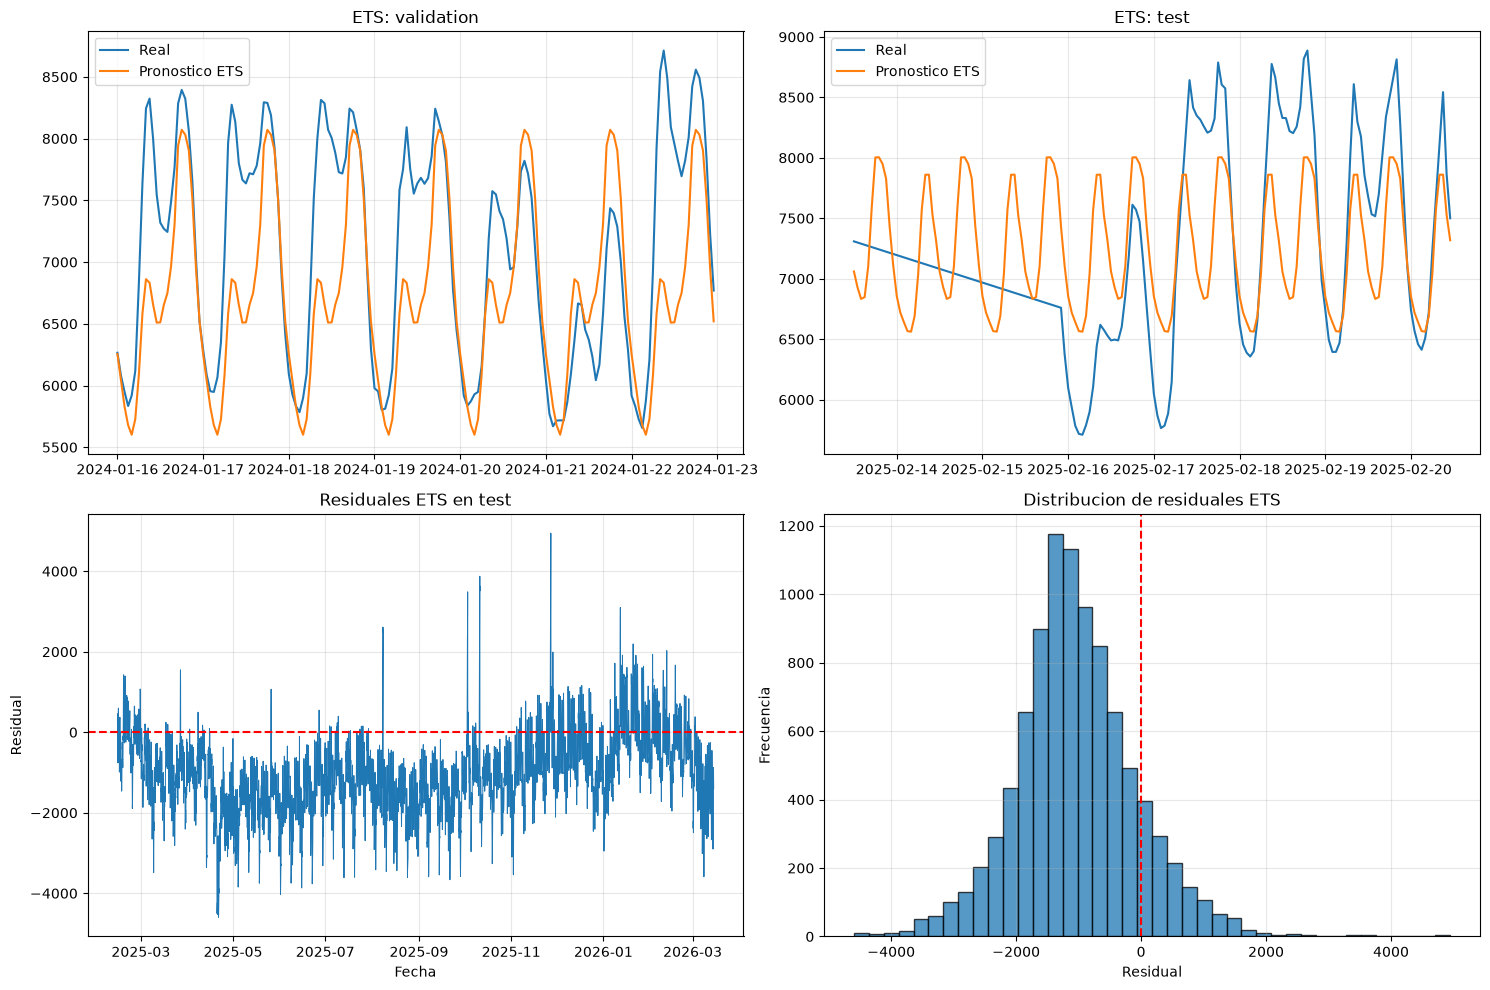

In [ ]:
# Diagnostico visual del modelo estructural ETS con regresores
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

validation_window = min(24 * 7, len(val_endog))
axes[0, 0].plot(val_endog.index[:validation_window], val_endog.iloc[:validation_window], label='Real')
axes[0, 0].plot(pred_val_ets.index[:validation_window], pred_val_ets.iloc[:validation_window], label='Pronostico ETS')
axes[0, 0].set_title('ETS con regresores: validation')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(test_endog.index[:validation_window], test_endog.iloc[:validation_window], label='Real')
axes[0, 1].plot(pred_test_ets.index[:validation_window], pred_test_ets.iloc[:validation_window], label='Pronostico ETS')
axes[0, 1].set_title('ETS con regresores: test')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

test_residuals_ets = test_endog.to_numpy() - pred_test_ets.to_numpy()
axes[1, 0].plot(test_endog.index, test_residuals_ets, linewidth=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Residuales en test')
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(test_residuals_ets, bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('Distribucion de residuales en test')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()